# Laboratório 06: Tratamento de Dados Raros e Alta Cardinalidade

**Disciplina:** Extração e Preparação de Dados (IBM8915)  
**Professor:** Luís Aramis

---

## 🎯 Objetivo

Compreender o impacto negativo da **alta cardinalidade** (o fenômeno da _cauda longa_) no desempenho de modelos analíticos. Você aprenderá a:

1. **Diagnosticar** a distribuição de frequência de variáveis categóricas.
2. **Decidir** um limiar de corte adequado ao contexto de negócio.
3. **Aplicar** técnicas do Pandas para agrupar categorias raras.

---

### 🗺️ Roteiro da Aula

| Parte | Tipo | Tempo estimado |
|---|---|---|
| **Parte 1** | Exemplo Guiado (Descoberta) | ~10 min |
| **Parte 2** | Exercício Prático | ~10 min |
| **Parte 3** | Desafio para Casa (Pipeline Completo) | ~30 min |

In [ ]:
# Setup inicial — execute esta célula antes de tudo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas carregadas com sucesso!")

---
## Parte 1: Exemplo Guiado — O Problema da Cauda Longa

Variáveis categóricas como `Cidade`, `Profissão` ou `Marca` costumam ter um comportamento típico: **poucos valores dominam** e **muitos valores aparecem raramente** (a chamada *cauda longa*).

Se treinarmos um modelo de Machine Learning com esses dados raros, ele irá **memorizar ruído** (overfitting) em vez de aprender padrões reais. A solução é o **Binning Categórico**: agrupar tudo que for raro na categoria `'Outros'`.

---

### 🔎 Passo 1 — Explore antes de rodar

Abaixo, criamos um dataset de 1.000 clientes com a coluna `Cidade`. Antes de executar qualquer célula, responda:

> **📝 Quantas cidades únicas você espera encontrar? Quais cidades acha que irão dominar os dados?**
>
> Espero encontrar 10 cidades e acho que as 3 maiores 'São Paulo', 'Rio de Janeiro', 'Belo Horizonte'. 

Agora execute a célula abaixo e veja o dataset.

In [ ]:
# Criando o dataset de cidades com alta cardinalidade
np.random.seed(42)
cidades_comuns = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte']
cidades_raras  = ['Cabo Frio', 'Itu', 'Bauru', 'Gramado', 'Ouro Preto', 'Ilhéus', 'Picos']

amostra_cidades = np.random.choice(cidades_comuns, 950, p=[0.6, 0.3, 0.1]).tolist()
amostra_cidades.extend(np.random.choice(cidades_raras, 50))

df_exemplo = pd.DataFrame({'ID_Cliente': range(1, 1001), 'Cidade': amostra_cidades})

print(f"Total de linhas: {len(df_exemplo)}")
print(f"Cidades únicas: {df_exemplo['Cidade'].nunique()}")
df_exemplo.head()

### 🔎 Passo 2 — Visualize a distribuição

A forma mais rápida de enxergar a *cauda longa* é com um gráfico de barras. Execute e observe:

> **📝 O gráfico evidenciou o que você esperava na sua hipótese? O que você percebe sobre a diferença de proporção entre as cidades comuns e raras?**
>
> Sim, as cidades que achei que iriam dominar os dados são as que apresentam maior frequência. 

In [ ]:
frequencias = df_exemplo['Cidade'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(10, 4))
frequencias.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(0.02, color='red', linestyle='--', linewidth=1.5, label='Limiar 2%')
ax.set_title('Proporção de Clientes por Cidade (antes do tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Proporção Original ---")
print(frequencias.to_string())

### 🔎 Passo 3 — Aplique a transformação

A linha vermelha tracejada no gráfico representa nosso **limiar de negócio**: qualquer cidade que aparecer em menos de 2% da base será agrupada como `'Outros'`. Execute e compare com o gráfico anterior.

In [ ]:
# Definindo o limiar
limite = 0.02
cidades_para_agrupar = frequencias[frequencias < limite].index

print(f"Cidades que serão agrupadas em 'Outros': {list(cidades_para_agrupar)}")

# Aplicando a transformação com .loc e .isin()
df_exemplo.loc[df_exemplo['Cidade'].isin(cidades_para_agrupar), 'Cidade'] = 'Outros'

# Visualização após tratamento
freq_apos = df_exemplo['Cidade'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(7, 4))
freq_apos.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Proporção de Clientes por Cidade (após tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print("\n--- Proporção Após Tratamento ---")
print(freq_apos.to_string())

### 💬 Reflexão — Parte 1

> **O que aconteceria com um modelo de ML se você tivesse treinado com as 10 cidades originais em vez das 4 categorias limpas?**  
> Pense especificamente em: *quantidade de colunas geradas pelo One-Hot Encoding* e *frequência de cada categoria no treino vs. teste*.

O modelo teria 10 features de cidade o que geraria ruído, comprometendo a análise. 


---

## Parte 2: Exercício Prático — Mão na Massa

Você extraiu um banco de dados de currículos. A coluna `Profissao` foi preenchida **manualmente** pelos usuários, gerando variações e erros típicos de dados do mundo real.

**Contexto:** O time de RH quer usar esses dados para treinar um modelo de triagem. Mas com tantas variações raras, o modelo irá decorar profissões que aparecem 1 ou 2 vezes, sem poder generalizá-las.

---

### 📝 Formule sua hipótese antes de começar

> Com um limiar de **3% (0.03)**, quantas profissões você acha que sobrarão após o tratamento? (Considere que há 3 profissões comuns e 8 raras)
>
> _Minha estimativa: 4 — Justificativa: são 3 profissões comuns + 'Outros'. 

Execute a célula abaixo para gerar os dados e depois escreva sua solução.

In [ ]:
# NÃO ALTERE ESTE CÓDIGO — Geração do cenário do exercício
profissoes_comuns = ['Engenheiro de Dados', 'Cientista de Dados', 'Analista de BI']
profissoes_raras  = ['Cientista de Dados Junior', 'Eng. de Dados', 'Programador',
                     'Estatístico', 'Matemático', 'Físico', 'Estagiário', 'Desenvolvedor Python']

amostra_profissoes = np.random.choice(profissoes_comuns, 400).tolist()
amostra_profissoes.extend(np.random.choice(profissoes_raras, 60))

df_rh = pd.DataFrame({'ID_Candidato': range(1, 461), 'Profissao': amostra_profissoes})

print(f"Total de candidatos: {len(df_rh)}")
print(f"Profissões únicas antes do tratamento: {df_rh['Profissao'].nunique()}")

In [ ]:
df_rh

In [ ]:
# Passo 1: Calcule as frequências relativas da coluna 'Profissao'
freq_profissoes = df_rh['Profissao'].value_counts(normalize=True)
fig, ax = plt.subplots(figsize=(10, 4))
freq_profissoes.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(0.03, color='red', linestyle='--', linewidth=1.5, label='Limiar 3%')
ax.set_title('Proporção de Profissões', fontsize=13)
ax.set_ylabel('frequêcia da profissão')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Proporção Original ---")
print(freq_profissoes.to_string())

In [ ]:
# Passo 2: Isole o índice das profissões com frequência < 0.03
limite = 0.03
profissoes_para_agrupar = freq_profissoes[freq_profissoes<limite].index
print(f"Profissões que serão agrupadas em 'Outros': {list(profissoes_para_agrupar)}")

# Passo 3: Substitua os valores raros por 'Outros' no df_rh
# Dica: use .loc com .isin()
# Aplicando a transformação com .loc e .isin()
df_rh.loc[df_rh['Profissao'].isin(profissoes_para_agrupar), 'Profissao'] = 'Outros'
freq_apos = df_rh['Profissao'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(7, 4))
freq_apos.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Proporção de Profissões por candidato (após tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Passo 4: Imprima o value_counts() final
print("\n--- Proporção Após Tratamento ---")
print(freq_apos.to_string())


In [ ]:
# ✅ CÉLULA DE VERIFICAÇÃO — Execute após completar o exercício
try:
    n_categorias = df_rh['Profissao'].nunique()
    assert n_categorias <= 4, (
        f"❌ Ainda há {n_categorias} categorias únicas. "
        "Verifique se o limiar de 0.03 foi aplicado corretamente."
    )
    assert 'Outros' in df_rh['Profissao'].values, (
        "❌ A categoria 'Outros' não foi encontrada. "
        "Certifique-se de usar exatamente a string 'Outros'."
    )
    print(f"✅ Parabéns! Cardinalidade reduzida para {n_categorias} categorias.")
    print("   O DataFrame df_rh está pronto para o One-Hot Encoding do Lab 07!")
except AssertionError as e:
    print(e)

### 💬 Reflexão — Parte 2

> 1. Sua hipótese estava correta? Se não, o que te surpreendeu?
Sim, após o binning resultamos em 4 categorias. 
> 2. **Questão de negócio:** Ao agrupar `'Eng. de Dados'` junto com `'Estagiário'` em `'Outros'`, você cometeu algum erro analítico? Como poderia mitigar isso?

Sim, porque existe uma hierarquia entre as profissões. Não faz sentido agrupar Estagiário que é um nível inicial com Engenheiro de Dados que já é um nível mais avançado. Ao colocar os dois em Outros, crio uma categoria heterogênea, o que pode: distorcer médias, 
esconder padrões importantes e gerar conclusões erradas.

Para mitigar isso poderíamos criar bins coerentes (ex: nível da profissão: júnior, pleno e senior). 

Além disso, teríamos que criar um mapeamento para não tratar uma mesma profissão, só que escrita de forma diferente, como duas (como é o caso de Engenheiro de Dados e Eng de Dados)



---

## Parte 3: Desafio para Casa — O Pipeline Completo

Este desafio consolida tudo das **Aulas 02 a 08**.  
Você irá trabalhar com um CSV sujo chamado `rais_amostra_suja.csv`, simulando a base pública da **Relação Anual de Informações Sociais (RAIS)** do Brasil.

---

### ⚠️ Importante: desta vez, o limiar é sua decisão!

Ao contrário dos exemplos anteriores, **não há um limiar definido** para a etapa 4.  
Você deve **explorar a distribuição** da coluna `Municipio` e **justificar analiticamente** o corte que escolher.

**A Missão:**

1. **(Aula 02):** Carregue o CSV com `sep=';'` e `encoding='latin-1'`.
2. **(Aula 05):** Audite e remova as linhas duplicadas.
3. **(Aula 07):** Preencha os nulos da coluna `Salario` com a Mediana.
4. **(Aula 08 — Decisão sua!):** Explore a distribuição de `Municipio`, escolha um limiar, justifique e aplique o agrupamento.
5. **(Aula 04):** Use `groupby` para calcular a **Média Salarial por Município** após a limpeza.

_O DataFrame limpo estará pronto para o One-Hot Encoding que faremos no `lab_07`!_ 🚀

In [53]:
# NÃO ALTERE ESTE CÓDIGO — Simulador de dados da RAIS
np.random.seed(10)

municipios = ['São Paulo - SP', 'Rio de Janeiro - RJ', 'Belo Horizonte - MG'] * 250 + \
             ['Campinas - SP', 'Niterói - RJ', 'Uberlândia - MG', 'Santos - RJ', 'Betim - MG'] * 50

df_rais = pd.DataFrame({
    'ID_Vinculo': np.random.randint(10000, 99999, len(municipios)),
    'Municipio':  municipios,
    'Salario':    np.random.normal(3500, 1200, len(municipios))
})

# Inserindo valores nulos
df_rais.loc[np.random.choice(len(df_rais), 100, replace=False), 'Salario'] = np.nan

# Inserindo duplicatas
df_rais = pd.concat([df_rais, df_rais.sample(80)], ignore_index=True)

# Embaralhando e exportando
df_rais = df_rais.sample(frac=1).reset_index(drop=True)
df_rais.to_csv('rais_amostra_suja.csv', sep=';', encoding='latin-1', index=False)
print(f"✅ Arquivo 'rais_amostra_suja.csv' gerado! ({len(df_rais)} linhas — com nulos e duplicatas)")

✅ Arquivo 'rais_amostra_suja.csv' gerado! (1080 linhas — com nulos e duplicatas)


In [54]:
# 1. Carregue o CSV (sep e encoding corretos)
df = pd.read_csv("/home/julia/IBMEC/ETL/data-extraction-course/Atividades/data/lab6/rais_amostra_suja.csv", sep = ";", encoding='latin-1')
print(f"Shape após carregamento: {df.shape}")

Shape após carregamento: (1080, 3)


In [55]:
# 2. Remova linhas duplicadas
df.duplicated().sum() #tem 80 registros duplicados 
df = df.drop_duplicates()
print(f"Shape após remoção dos duplicados: {df.shape}")

Shape após remoção dos duplicados: (1000, 3)


In [57]:
# 4a. EXPLORE a distribuição de Municipio (obrigatório antes de definir o limiar)
df['Municipio'].describe()
# Plote um gráfico de barras com as proporções e adicione uma linha horizontal

# no limiar que você pretende usar.
freq_municipios = df['Municipio'].value_counts(normalize=True)
freq_municipios

Municipio
São Paulo - SP         0.25
Rio de Janeiro - RJ    0.25
Belo Horizonte - MG    0.25
Niterói - RJ           0.05
Santos - RJ            0.05
Betim - MG             0.05
Campinas - SP          0.05
Uberlândia - MG        0.05
Name: proportion, dtype: float64

Munícipios que serão agrupadas em 'Outros': ['Niterói - RJ', 'Santos - RJ', 'Betim - MG', 'Campinas - SP', 'Uberlândia - MG']


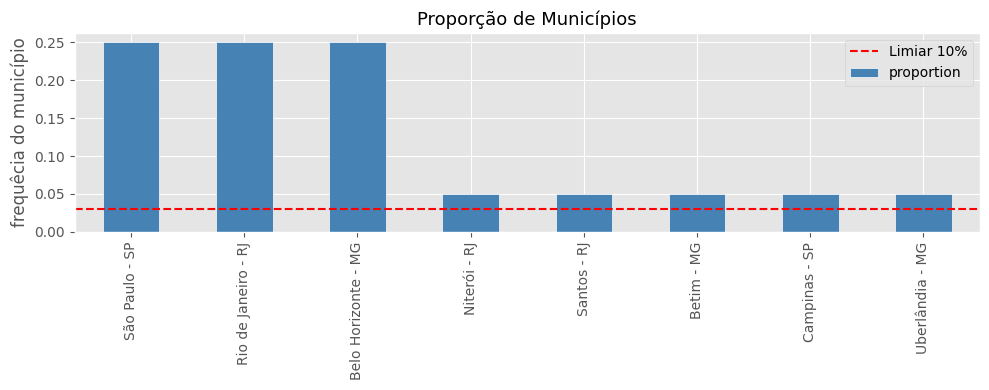


--- Proporção Original ---
Municipio
São Paulo - SP         0.25
Rio de Janeiro - RJ    0.25
Belo Horizonte - MG    0.25
Niterói - RJ           0.05
Santos - RJ            0.05
Betim - MG             0.05
Campinas - SP          0.05
Uberlândia - MG        0.05


In [58]:
#Proporção de Municípios 
limite = 0.1
municipios_para_agrupar = freq_municipios[freq_municipios<limite].index
print(f"Munícipios que serão agrupadas em 'Outros': {list(municipios_para_agrupar)}")

fig, ax = plt.subplots(figsize=(10, 4))
freq_municipios.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(0.03, color='red', linestyle='--', linewidth=1.5, label='Limiar 10%')
ax.set_title('Proporção de Municípios', fontsize=13)
ax.set_ylabel('frequêcia do município')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()
print("\n--- Proporção Original ---")
print(freq_municipios.to_string())

### 📝 Justificativa do Limiar (obrigatório)

> Com base no gráfico acima, defina o limiar que você vai usar e justifique:
>
> **Limiar escolhido:** 
Escolhi o limiar de 10%, visto que existiam 5 municípios com proporção de 5% e 3 com proporção de 25%. 
>
> **Justificativa:** [Por que este corte faz sentido analítico para esta base?]

Esse limiar de 10% para conseguir tirar os ruídos (cidades com menos de 5% de proporção) 

> [Quais municípios ficam de fora e isso é aceitável?]

Niterói - RJ, Santos - RJ, Betim - MG, Campinas - SP, Uberlândia - MG. 


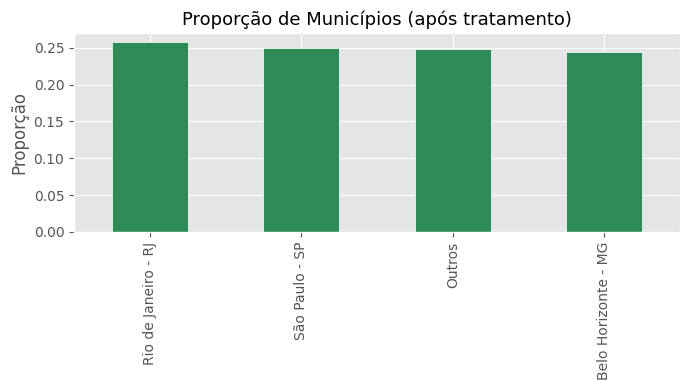


--- Proporção Após Tratamento ---
Municipio
Rio de Janeiro - RJ    0.257407
São Paulo - SP         0.250000
Outros                 0.248148
Belo Horizonte - MG    0.244444
Municípios únicos antes: 8
Municípios únicos depois: 4


In [59]:
# 4b. APLIQUE a redução de cardinalidade com o limiar que você justificou acima
df_rais.loc[df_rais['Municipio'].isin(municipios_para_agrupar), 'Municipio'] = 'Outros'
freq_apos = df_rais['Municipio'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(7, 4))
freq_apos.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Proporção de Municípios (após tratamento)', fontsize=13)
ax.set_ylabel('Proporção')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

#Imprima o value_counts() final
print("\n--- Proporção Após Tratamento ---")
print(freq_apos.to_string())

print(f"Municípios únicos antes: {freq_municipios.shape[0]}")
print(f"Municípios únicos depois: {df_rais['Municipio'].nunique()}")

In [70]:
#Preencher valores de salário nulos com a mediana do salário 
df_rais['Salario'].isna().sum() #112 valores de salário nulos 
mediana = df_rais['Salario'].median
df_rais['Salario'] = df_rais['Salario'].fillna(mediana)

#conversão de salário para numérico:
df_rais["Salario"] = pd.to_numeric(df_rais["Salario"], errors="coerce")

In [ ]:
# 5. Análise agrupada — Média Salarial por Município limpo
# Use groupby + mean e ordene do maior para o menor
df_media_salarial = df_rais.groupby("Municipio")["Salario"].mean()
df_media_salarial.sort_values(ascending=False)

Municipio
Rio de Janeiro - RJ    3540.612587
Outros                 3533.590648
Belo Horizonte - MG    3484.847790
São Paulo - SP         3406.297482
Name: Salario, dtype: float64

### 💬 Reflexão Final

> 1. O município `'Outros'` ficou com salário médio acima ou abaixo dos municípios individuais? O que isso pode significar?

O município 'Outros' ficou com salário médio acima dos municípios Belo Horizonte e São Paulo. Isso significa que provavelmente os municípios que estão em Outros tem média salarial mais alta. 

> 2. Se você fosse apresentar este resultado para um gestor de RH, o que você **não** poderia afirmar com base apenas nesta análise?

Não seria possível afirmar que os municípios agrupados em “Outros” realmente pagam salários maiores de forma geral.
Isso porque o grupo “Outros” reúne vários municípios diferentes, e a média calculada pode estar sendo influenciada por apenas um ou dois municípios com salários mais altos.
Portanto, a média salarial por município não permite concluir causalidade nem comparar qualidade salarial entre regiões de forma definitiva.

> 3. O que aconteceria na prática se você rodasse `pd.get_dummies()` sobre `Municipio` **sem** ter feito a redução de cardinalidade?

Se pd.get_dummies() fosse aplicado diretamente, seriam criadas muitas colunas novas, uma para cada município, o que aumentaria muito a dimensionalidade do dataset sendo que muitas dessas colunas teriam pouquíssimas observações (dados raros).
Isso causaria num maior consumo de memória e processamento para o modelo de ML. 

---

**🎓 Parabéns por concluir o Lab 06!**  
No próximo laboratório (`lab_07_encoders.ipynb`), aplicaremos `pd.get_dummies()` sobre este DataFrame já limpo. Você verá exatamente por que o pré-processamento de hoje era indispensável.